# Demand Prediction Agent

## Objective

The objective of this notebook is to develop a machine learning model capable of forecasting EV charging demand using historical charging station data.

The model will learn relationships between charging demand and operational factors such as:

- Occupancy
- Electricity Price
- Hour of Day
- Day of Month
- Month
- Weekend Indicator
- Previous Price

Accurate demand forecasts will later be used by the Tariff Pricing Agent to recommend dynamic charging prices.

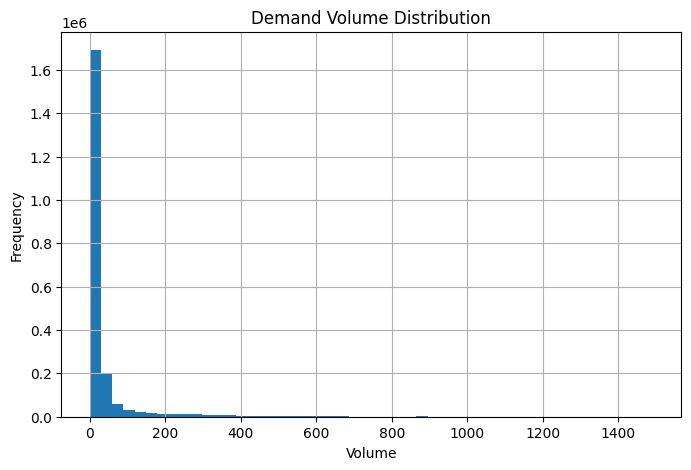

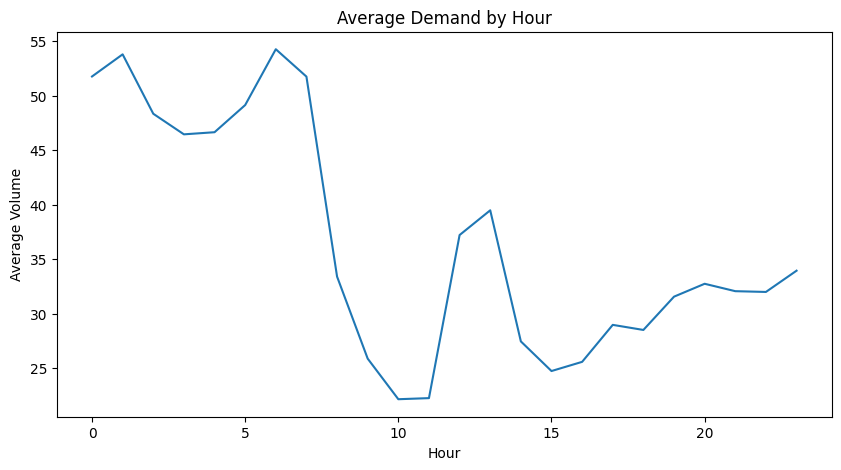

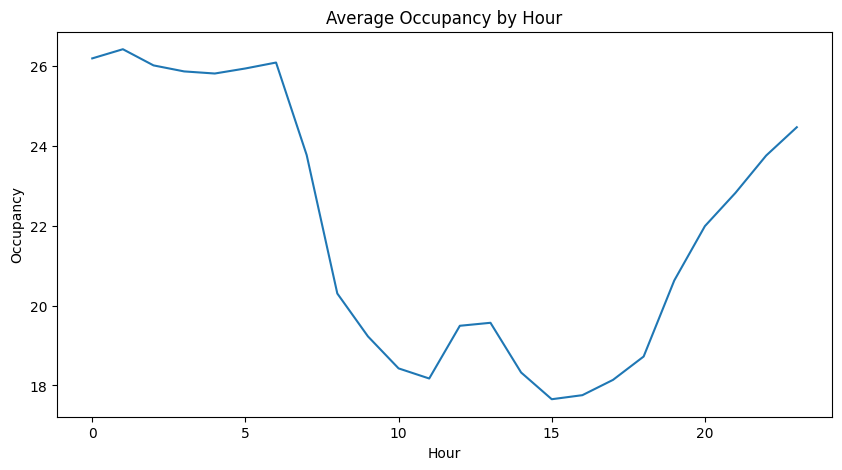

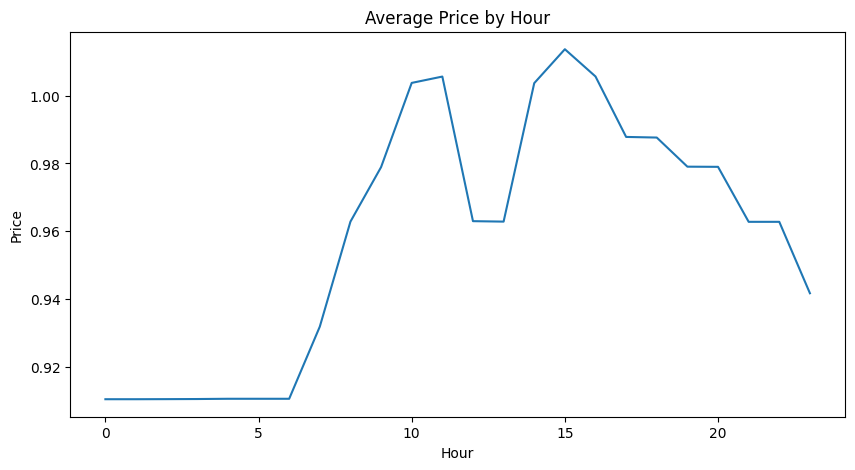

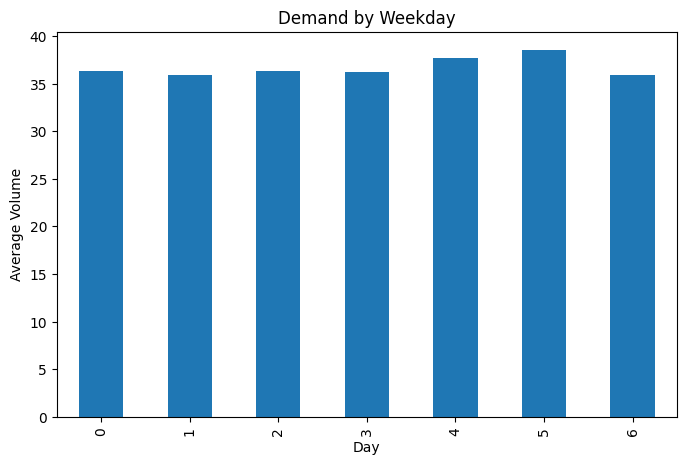

grid
595     736.958895
1131    611.374595
1167    497.286254
633     441.480751
1137    388.334273
576     366.622762
333     293.836927
1026    265.702572
775     249.704807
690     226.762567
Name: volume, dtype: float64


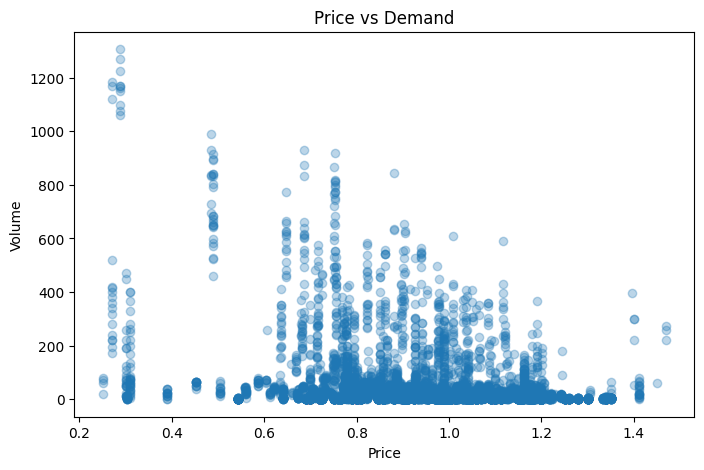

In [100]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("urbanev_merged.csv")

df["datetime"] = pd.to_datetime(df["datetime"])

df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.dayofweek


plt.figure(figsize=(8,5))
df["volume"].hist(bins=50)

plt.title("Demand Volume Distribution")
plt.xlabel("Volume")
plt.ylabel("Frequency")

plt.show()

hourly = df.groupby("hour")["volume"].mean()

plt.figure(figsize=(10,5))
hourly.plot()

plt.title("Average Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Volume")

plt.show()
hourly_occ = df.groupby("hour")["occupancy"].mean()

plt.figure(figsize=(10,5))
hourly_occ.plot()

plt.title("Average Occupancy by Hour")
plt.xlabel("Hour")
plt.ylabel("Occupancy")

plt.show()

hourly_price = df.groupby("hour")["price"].mean()

plt.figure(figsize=(10,5))
hourly_price.plot()

plt.title("Average Price by Hour")
plt.xlabel("Hour")
plt.ylabel("Price")

plt.show()

weekday_demand = df.groupby("weekday")["volume"].mean()

plt.figure(figsize=(8,5))
weekday_demand.plot(kind="bar")

plt.title("Demand by Weekday")
plt.xlabel("Day")
plt.ylabel("Average Volume")

plt.show()

top_grids = (
    df.groupby("grid")["volume"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(top_grids)


sample = df.sample(10000)

plt.figure(figsize=(8,5))
plt.scatter(
    sample["price"],
    sample["volume"],
    alpha=0.3
)

plt.xlabel("Price")
plt.ylabel("Volume")
plt.title("Price vs Demand")

plt.show()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   _id                   4803 non-null   str    
 1   userInputs            28 non-null     str    
 2   sessionID             4803 non-null   str    
 3   stationID             4803 non-null   str    
 4   spaceID               4803 non-null   str    
 5   siteID                4803 non-null   int64  
 6   clusterID             4803 non-null   int64  
 7   connectionTime        4803 non-null   str    
 8   disconnectTime        4803 non-null   str    
 9   kWhDelivered          4803 non-null   float64
 10  doneChargingTime      4803 non-null   str    
 11  timezone              4803 non-null   str    
 12  userID                28 non-null     float64
 13  session_duration_hr   4803 non-null   float64
 14  charging_duration_hr  4803 non-null   float64
 15  idle_duration_hr      4803 non-n

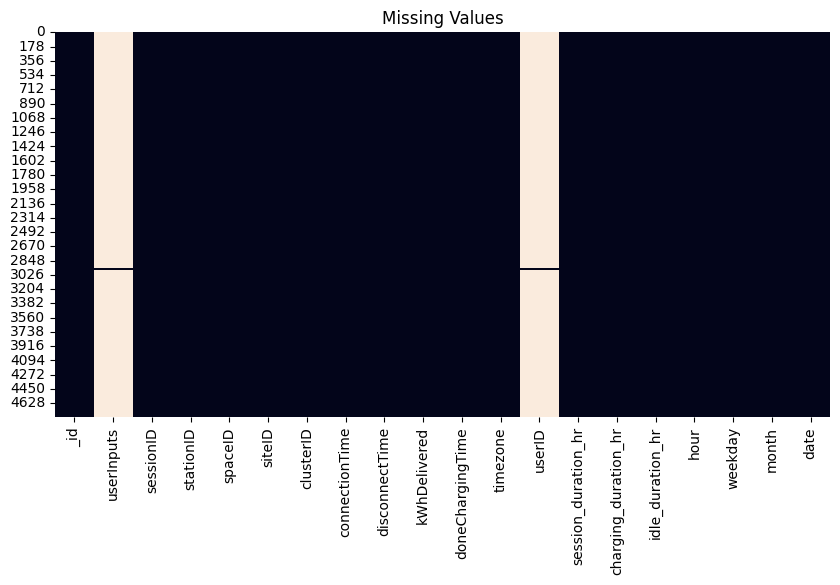

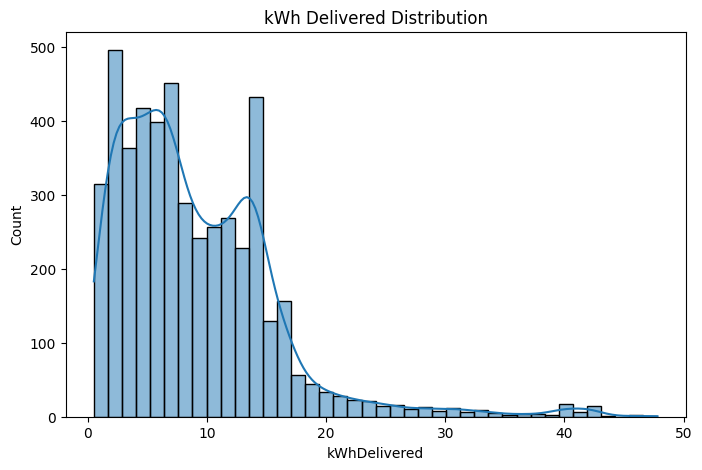

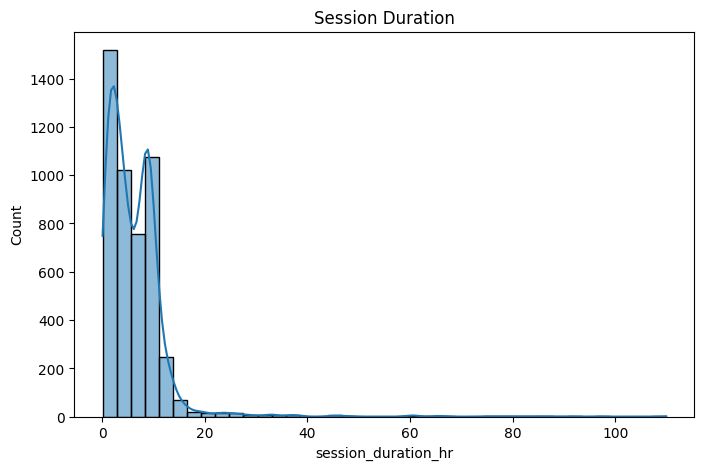

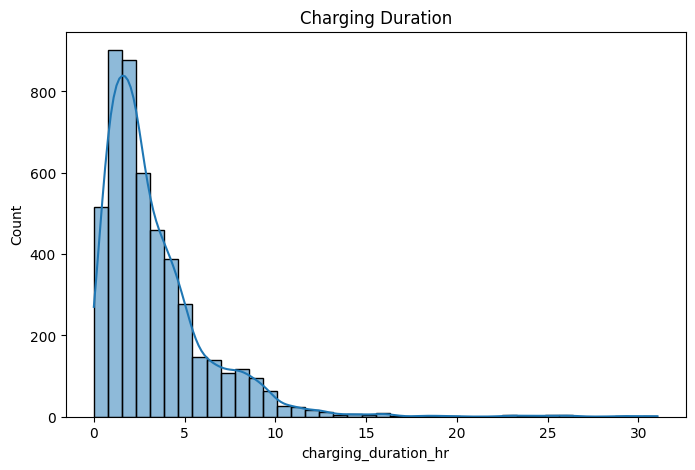

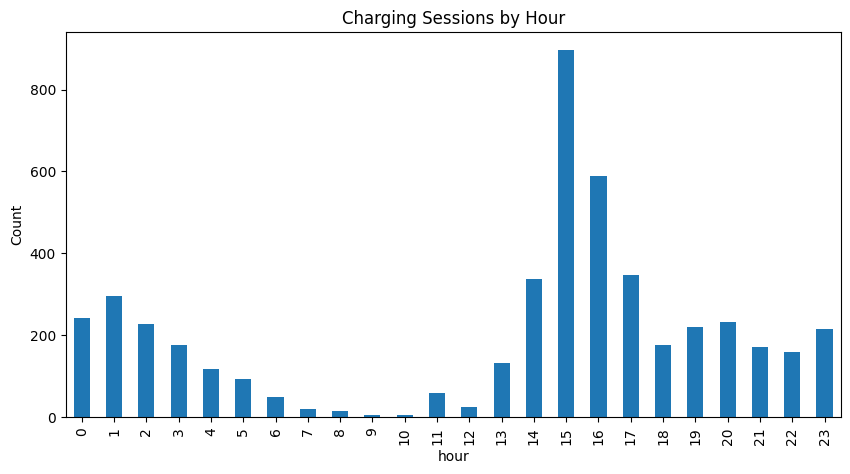

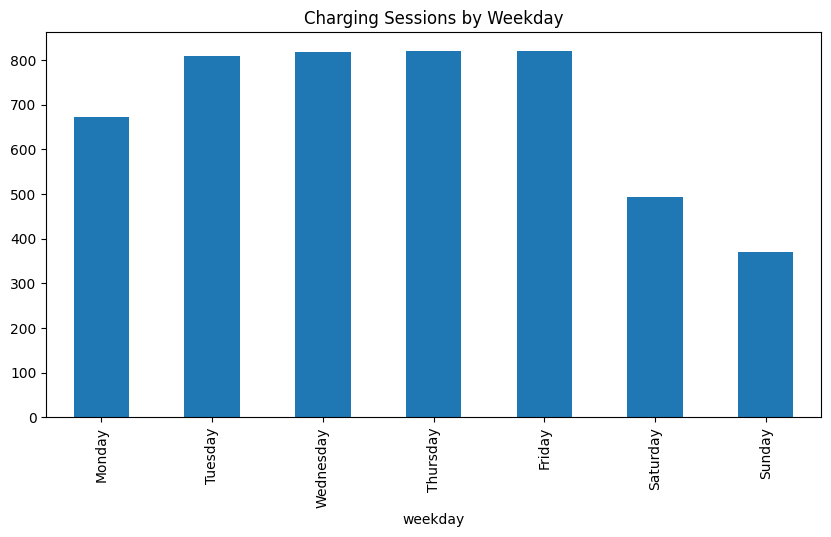

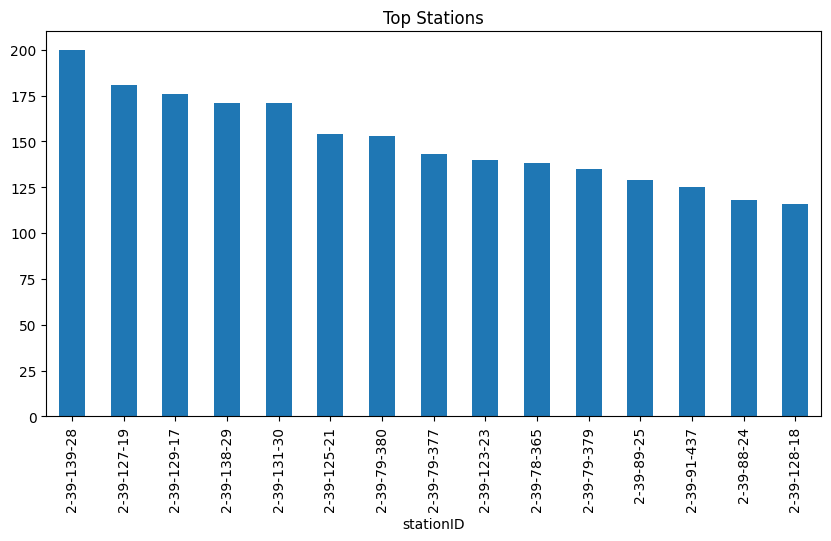

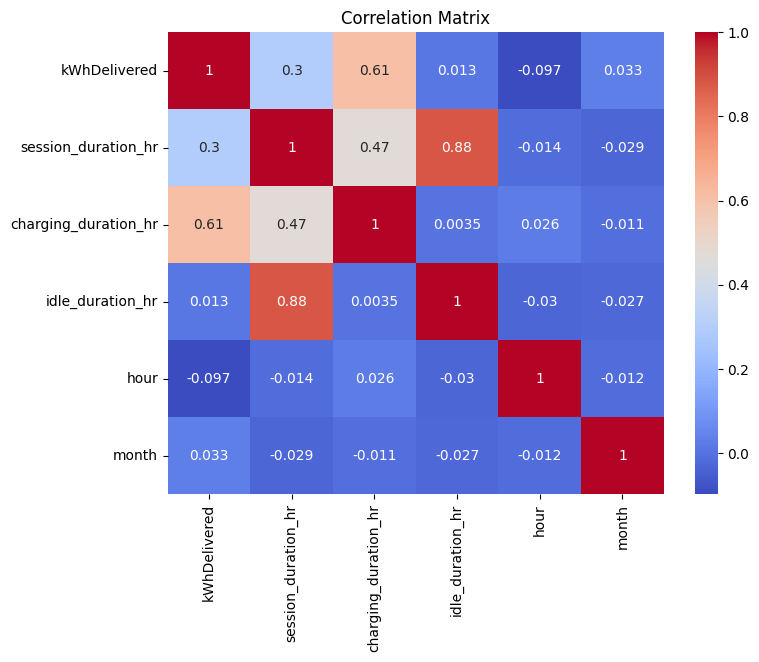

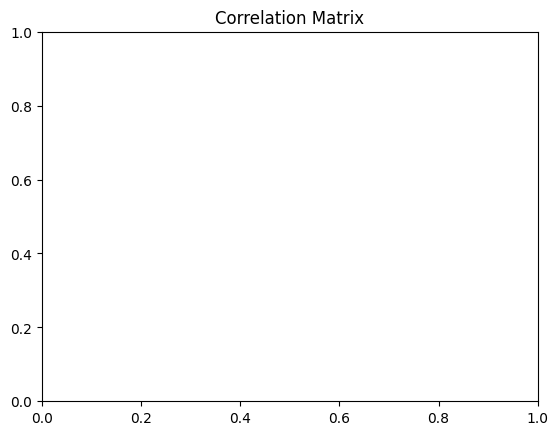

Average kWh Delivered: 9.00953017962502
Maximum kWh Delivered: 47.808
stationID
2-39-139-28    200
2-39-127-19    181
2-39-129-17    176
2-39-138-29    171
2-39-131-30    171
2-39-125-21    154
2-39-79-380    153
2-39-79-377    143
2-39-123-23    140
2-39-78-365    138
dtype: int64


In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("acn_clean.csv")

# ---------- BASIC INFO ----------
print(df.info())
print(df.describe())

# ---------- MISSING VALUES ----------
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

# ---------- KWH DELIVERED ----------
plt.figure(figsize=(8,5))
sns.histplot(df["kWhDelivered"], bins=40, kde=True)
plt.title("kWh Delivered Distribution")
plt.show()

# ---------- SESSION DURATION ----------
plt.figure(figsize=(8,5))
sns.histplot(df["session_duration_hr"], bins=40, kde=True)
plt.title("Session Duration")
plt.show()

# ---------- CHARGING DURATION ----------
plt.figure(figsize=(8,5))
sns.histplot(df["charging_duration_hr"], bins=40, kde=True)
plt.title("Charging Duration")
plt.show()

# ---------- HOURLY DEMAND ----------
hourly = df.groupby("hour").size()

plt.figure(figsize=(10,5))
hourly.plot(kind="bar")
plt.title("Charging Sessions by Hour")
plt.ylabel("Count")
plt.show()

# ---------- WEEKDAY DEMAND ----------
weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

weekday_counts = (
    df["weekday"]
    .value_counts()
    .reindex(weekday_order)
)

plt.figure(figsize=(10,5))
weekday_counts.plot(kind="bar")
plt.title("Charging Sessions by Weekday")
plt.show()

# ---------- TOP STATIONS ----------
top = df["stationID"].value_counts().head(15)

plt.figure(figsize=(10,5))
top.plot(kind="bar")
plt.title("Top Stations")
plt.show()

# ---------- CORRELATION ----------
num_cols = [
    "kWhDelivered",
    "session_duration_hr",
    "charging_duration_hr",
    "idle_duration_hr",
    "hour",
    "month"
]

corr_matrix = df[num_cols].select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()
plt.title("Correlation Matrix")
plt.show()

print("Average kWh Delivered:", df["kWhDelivered"].mean())
print("Maximum kWh Delivered:", df["kWhDelivered"].max())

station_usage = (
    df.groupby("stationID")
      .size()
      .sort_values(ascending=False)
)

print(station_usage.head(10))

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

volume = pd.read_csv("urbanev/volume.csv")
occupancy = pd.read_csv("urbanev/occupancy.csv")
duration = pd.read_csv("urbanev/duration.csv")
price = pd.read_csv("urbanev/price.csv")
time_df = pd.read_csv("urbanev/time.csv")

print("Volume:", volume.shape)
print("Occupancy:", occupancy.shape)
print("Duration:", duration.shape)
print("Price:", price.shape)
print("Time:", time_df.shape)

Volume: (8640, 248)
Occupancy: (8640, 248)
Duration: (8640, 248)
Price: (8640, 248)
Time: (8640, 6)


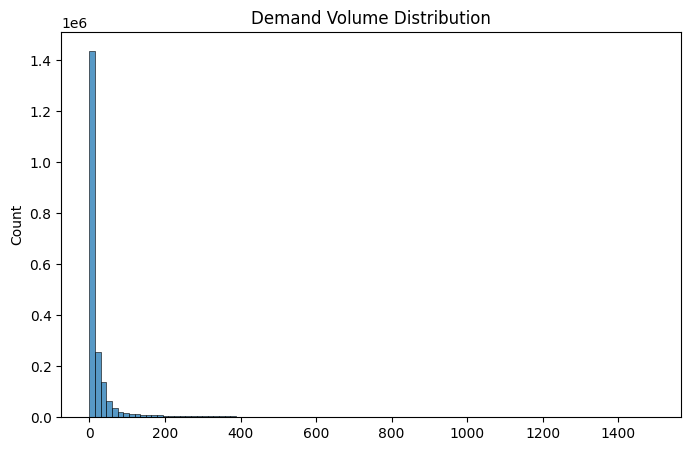

In [103]:
vol = volume.drop(columns=["timestamp"])

plt.figure(figsize=(8,5))
sns.histplot(vol.values.flatten(), bins=100)
plt.title("Demand Volume Distribution")
plt.show()

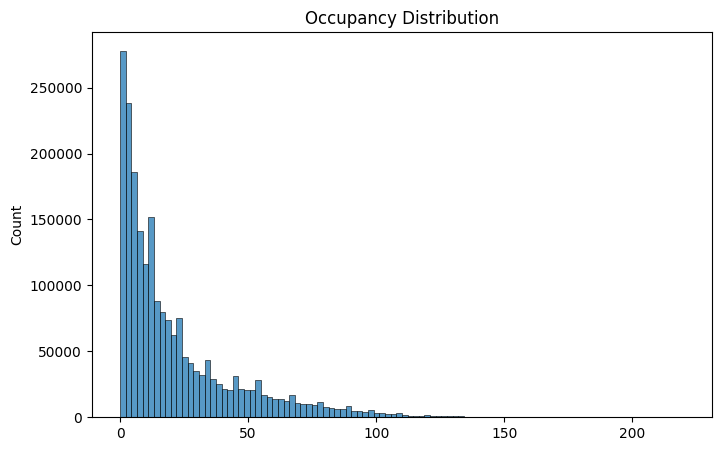

In [104]:
occ = occupancy.drop(columns=["timestamp"])

plt.figure(figsize=(8,5))
sns.histplot(occ.values.flatten(), bins=100)
plt.title("Occupancy Distribution")
plt.show()

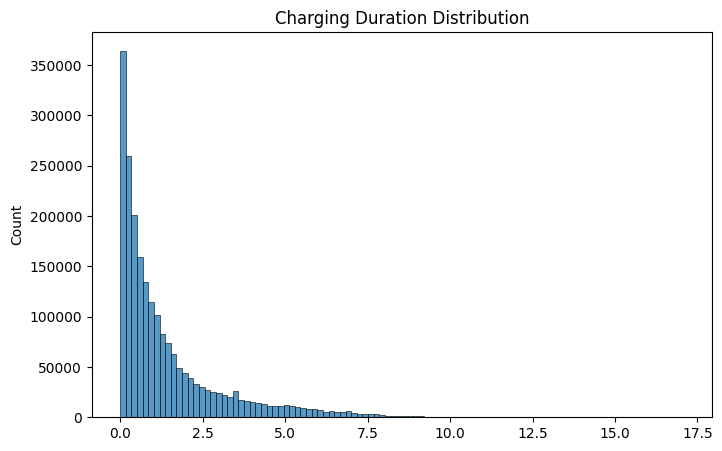

In [105]:
dur = duration.drop(columns=["timestamp"])

plt.figure(figsize=(8,5))
sns.histplot(dur.values.flatten(), bins=100)
plt.title("Charging Duration Distribution")
plt.show()

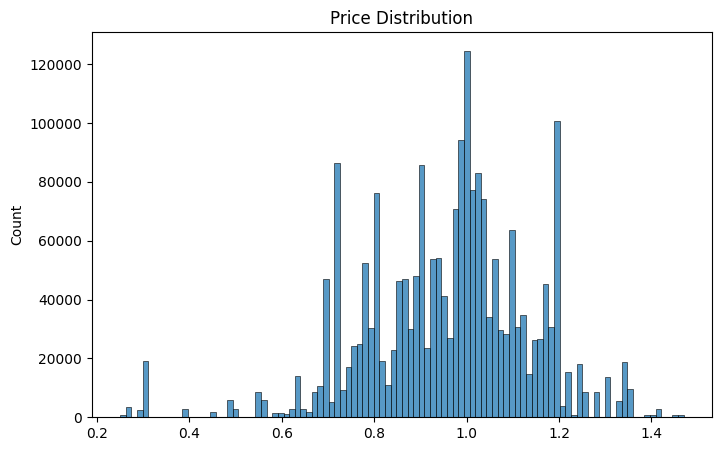

In [106]:
pr = price.drop(columns=["timestamp"])

plt.figure(figsize=(8,5))
sns.histplot(pr.values.flatten(), bins=100)
plt.title("Price Distribution")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_16336\1715508180.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  volume["avg_volume"] = (


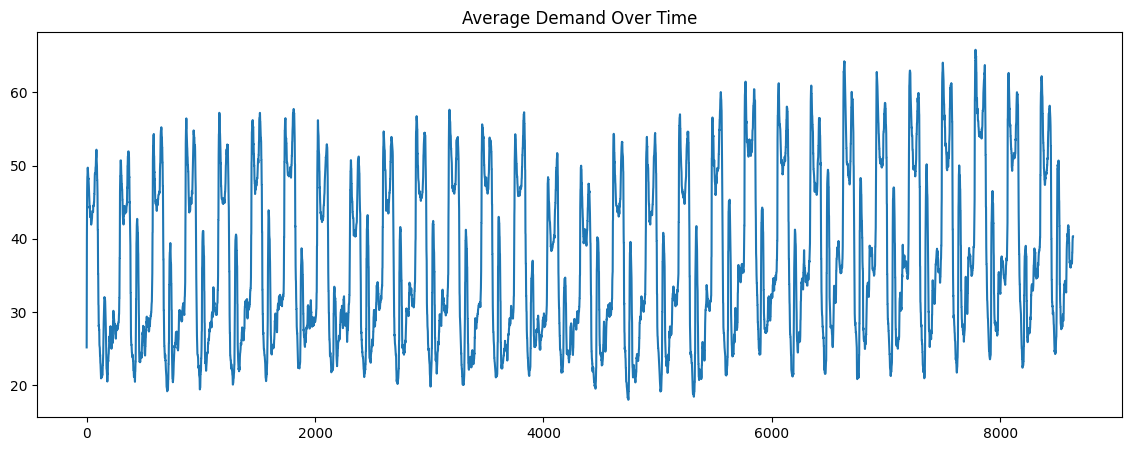

In [107]:
volume["avg_volume"] = (
    volume.drop(columns=["timestamp"])
    .mean(axis=1)
)

plt.figure(figsize=(14,5))
plt.plot(volume["avg_volume"])
plt.title("Average Demand Over Time")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_16336\1204166398.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  occupancy["avg_occ"] = (


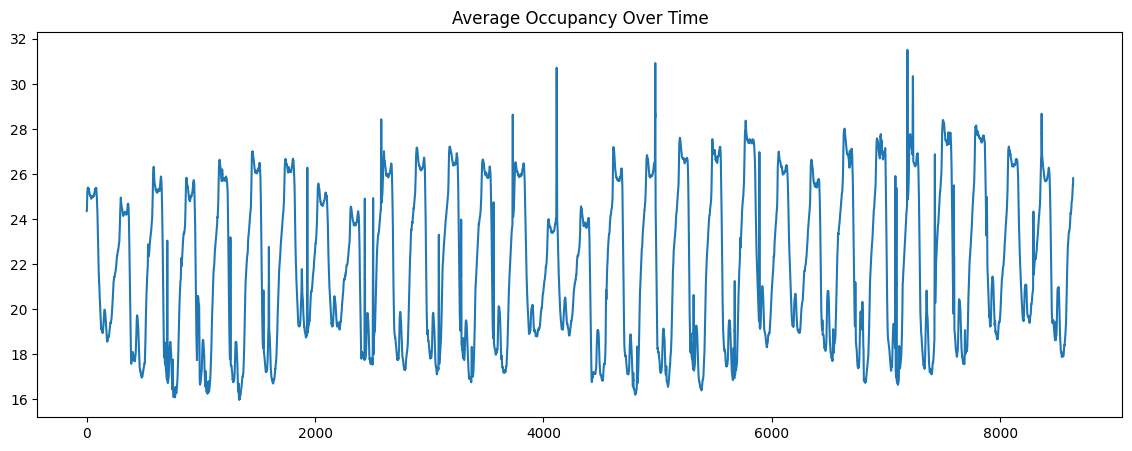

In [108]:
occupancy["avg_occ"] = (
    occupancy.drop(columns=["timestamp"])
    .mean(axis=1)
)

plt.figure(figsize=(14,5))
plt.plot(occupancy["avg_occ"])
plt.title("Average Occupancy Over Time")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_16336\626793319.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  price["avg_price"] = (


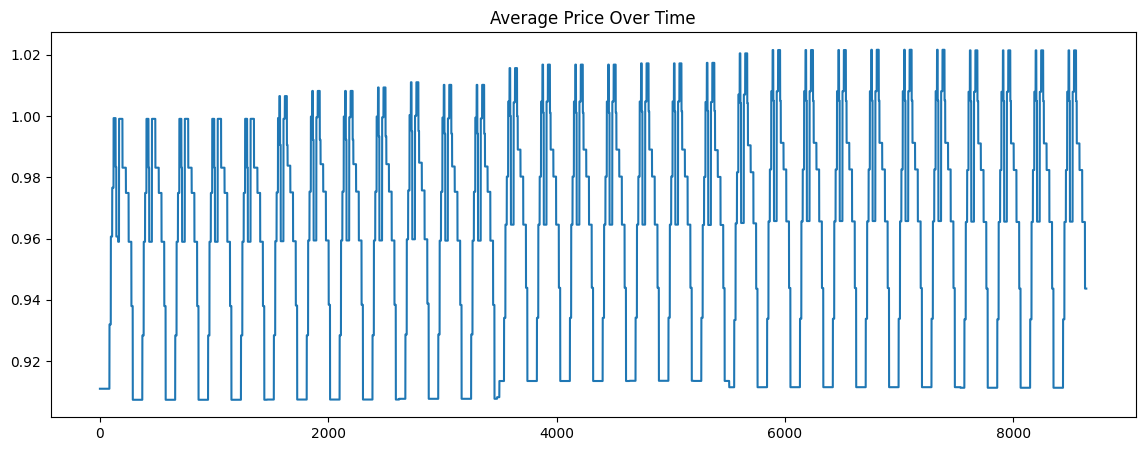

In [109]:
price["avg_price"] = (
    price.drop(columns=["timestamp"])
    .mean(axis=1)
)

plt.figure(figsize=(14,5))
plt.plot(price["avg_price"])
plt.title("Average Price Over Time")
plt.show()

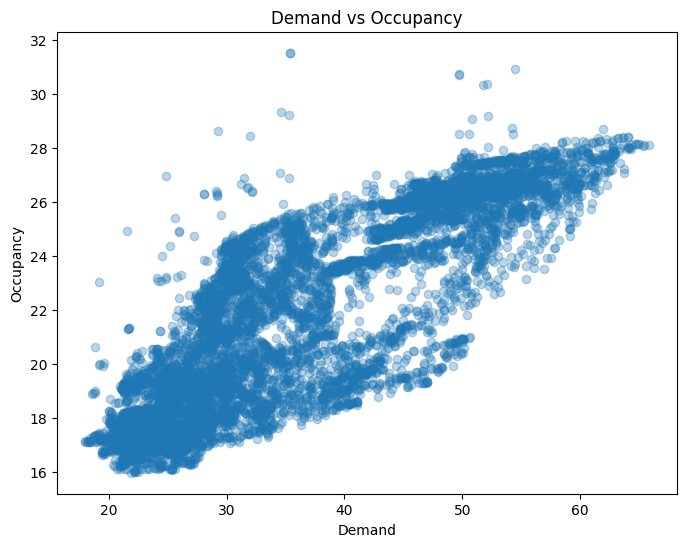

In [110]:
demand = (
    volume.drop(columns=["timestamp"])
    .mean(axis=1)
)

occ = (
    occupancy.drop(columns=["timestamp"])
    .mean(axis=1)
)

plt.figure(figsize=(8,6))
plt.scatter(demand, occ, alpha=0.3)
plt.xlabel("Demand")
plt.ylabel("Occupancy")
plt.title("Demand vs Occupancy")
plt.show()

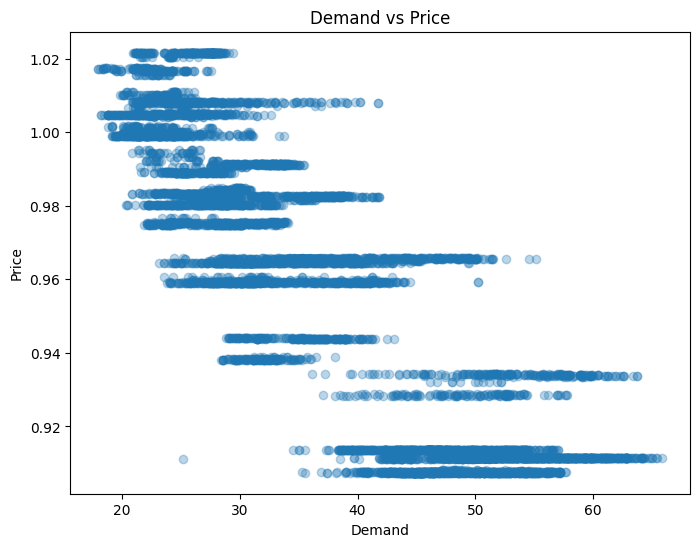

In [111]:
price_avg = (
    price.drop(columns=["timestamp"])
    .mean(axis=1)
)

plt.figure(figsize=(8,6))
plt.scatter(demand, price_avg, alpha=0.3)
plt.xlabel("Demand")
plt.ylabel("Price")
plt.title("Demand vs Price")
plt.show()

In [112]:
print(dir())

['In', 'Out', 'PS1', 'REPLHooks', 'RandomForestRegressor', 'X', 'X_no_prev', 'X_test', 'X_train', '_', '_22', '_29', '_35', '_52', '_59', '_65', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__session__', '__spec__', '_dh', '_i', '_i1', '_i10', '_i100', '_i101', '_i102', '_i103', '_i104', '_i105', '_i106', '_i107', '_i108', '_i109', '_i11', '_i110', '_i111', '_i112', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i3', '_i30', '_i31', '_i32', '_i33', '_i34', '_i35', '_i36', '_i37', '_i38', '_i39', '_i4', '_i40', '_i41', '_i42', '_i43', '_i44', '_i45', '_i46', '_i47', '_i48', '_i49', '_i5', '_i50', '_i51', '_i52', '_i53', '_i54', '_i55', '_i56', '_i57', '_i58', '_i59', '_i6', '_i60', '_i61', '_i62', '_i63', '_i64', '_i65', '_i66', '_i67', '_i68', '_i69', '_i7', '_i70', '_i71', '_i72', '_i73', '_i74', '_i75', '_i76', '_i77', '_i78', '

In [113]:
print(type(hourly))
print

<class 'pandas.Series'>


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [114]:
print(hourly.head())

hour
0    241
1    295
2    228
3    175
4    117
dtype: int64


In [115]:
print("VOLUME")
print(volume.isnull().sum().sum())

print("OCCUPANCY")
print(occupancy.isnull().sum().sum())

print("DURATION")
print(duration.isnull().sum().sum())

print("PRICE")
print(price.isnull().sum().sum())

VOLUME
0
OCCUPANCY
0
DURATION
0
PRICE
0


In [116]:
print(dir())


['In', 'Out', 'PS1', 'REPLHooks', 'RandomForestRegressor', 'X', 'X_no_prev', 'X_test', 'X_train', '_', '_113', '_22', '_29', '_35', '_52', '_59', '_65', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__session__', '__spec__', '_dh', '_i', '_i1', '_i10', '_i100', '_i101', '_i102', '_i103', '_i104', '_i105', '_i106', '_i107', '_i108', '_i109', '_i11', '_i110', '_i111', '_i112', '_i113', '_i114', '_i115', '_i116', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i3', '_i30', '_i31', '_i32', '_i33', '_i34', '_i35', '_i36', '_i37', '_i38', '_i39', '_i4', '_i40', '_i41', '_i42', '_i43', '_i44', '_i45', '_i46', '_i47', '_i48', '_i49', '_i5', '_i50', '_i51', '_i52', '_i53', '_i54', '_i55', '_i56', '_i57', '_i58', '_i59', '_i6', '_i60', '_i61', '_i62', '_i63', '_i64', '_i65', '_i66', '_i67', '_i68', '_i69', '_i7', '_i70', '_i71', '_i72', '_i73

In [117]:
for name, df in {
    "Volume": volume,
    "Occupancy": occupancy,
    "Duration": duration,
    "Price": price
}.items():

    print("\n", name)
    print(df.describe())


 Volume
         timestamp          102          105          107          108  \
count  8640.000000  8640.000000  8640.000000  8640.000000  8640.000000   
mean   4320.500000     5.336029     6.656212     7.228926     7.373510   
std    2494.297496     1.153703     1.817421     2.520186     1.918755   
min       1.000000     2.041667     1.750000     1.750000     2.625000   
25%    2160.750000     4.483403     5.250000     5.250000     6.125000   
50%    4320.500000     5.250000     6.416667     7.000000     7.493889   
75%    6480.250000     6.125000     7.875000     8.750000     8.750000   
max    8640.000000     9.625000    11.958333    17.833333    12.541667   

               109          110          111          115          123  ...  \
count  8640.000000  8640.000000  8640.000000  8640.000000  8640.000000  ...   
mean      3.600911     4.352091     5.548345     0.647816     1.851793  ...   
std       1.597982     1.463044     1.341634     0.539588     0.970376  ...   
min     

In [118]:
merged = pd.DataFrame({
    "demand": volume["avg_volume"],
    "occupancy": occupancy["avg_occ"],
    "price": price["avg_price"]
})

In [119]:
merged = pd.DataFrame({
    "demand": volume["avg_volume"],
    "occupancy": occupancy["avg_occ"],
    "price": price["avg_price"]
})

In [120]:
merged.corr()

,demand,occupancy,price
demand,1.000000,0.840295,-0.862787
occupancy,0.840295,1.000000,-0.875036
price,-0.862787,-0.875036,1.000000


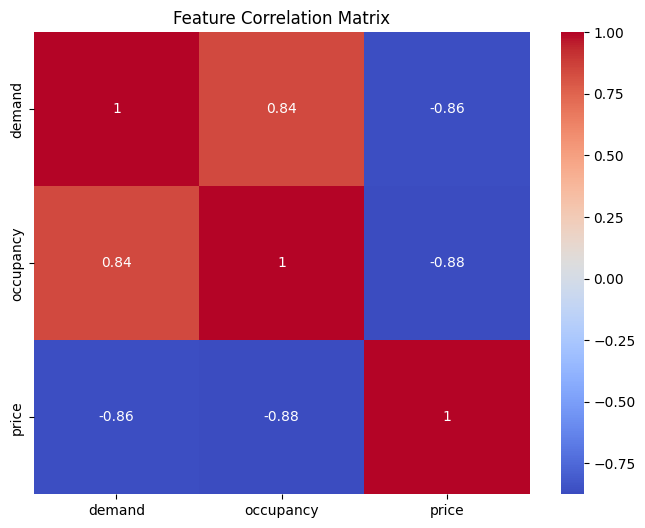

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    merged.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

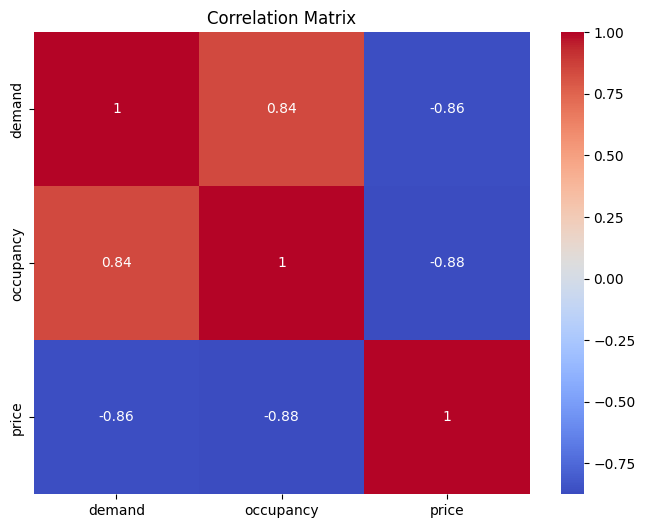

In [122]:
plt.figure(figsize=(8,6))
sns.heatmap(
    merged.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

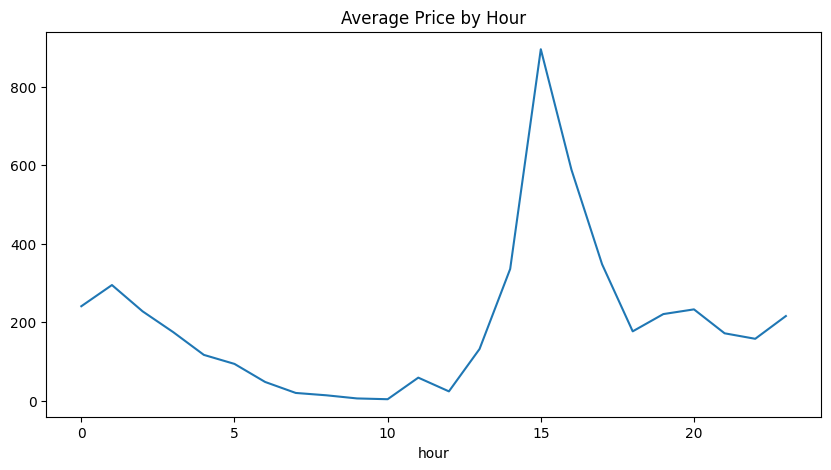

In [123]:
hourly.plot(figsize=(10,5))
plt.title("Average Price by Hour")
plt.show()

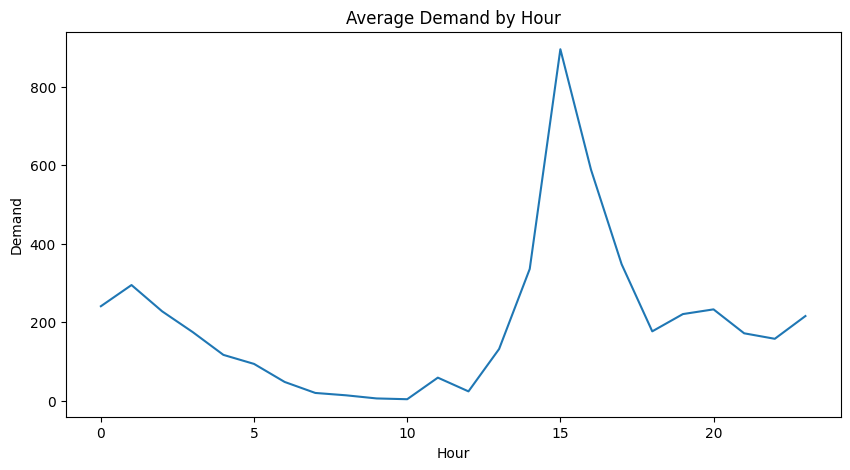

In [124]:
plt.figure(figsize=(10,5))

plt.plot(
    hourly.index,
    hourly.values
)

plt.title("Average Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Demand")

plt.show()

## Data Loading and Preparation

The UrbanEV dataset is loaded and transformed into a unified analytical dataset.

Average values across charging stations are calculated for:

- Demand
- Occupancy
- Price

Additional temporal features are added to capture charging behavior patterns over time.

In [125]:
import pandas as pd

volume = pd.read_csv("urbanev/volume.csv")
occupancy = pd.read_csv("urbanev/occupancy.csv")
price = pd.read_csv("urbanev/price.csv")
time_df = pd.read_csv("urbanev/time.csv")

volume_avg = (
    volume.drop(columns=["timestamp"])
    .mean(axis=1)
)

occupancy_avg = (
    occupancy.drop(columns=["timestamp"])
    .mean(axis=1)
)

price_avg = (
    price.drop(columns=["timestamp"])
    .mean(axis=1)
)

### Dataset Summary

The merged dataset contains:

- Demand (Target Variable)
- Occupancy
- Charging Price
- Hour
- Day
- Month
- Weekend Indicator
- Previous Price

The final dataset contains 8,639 charging intervals after preprocessing.

In [126]:
merged = pd.DataFrame({
    "demand": volume_avg,
    "occupancy": occupancy_avg,
    "price": price_avg
})

merged["hour"] = time_df["hour"]
merged["day"] = time_df["day"]
merged["month"] = time_df["month"]

merged["is_weekend"] = (
    merged["day"] >= 5
).astype(int)

merged["prev_price"] = merged["price"].shift(1)

merged = merged.dropna()

print(merged.shape)
merged.head()

(8639, 8)


,demand,occupancy,price,hour,day,month,is_weekend,prev_price
1,38.514720,24.356275,0.911018,0,19,6,1,0.911018
2,40.093327,24.643725,0.911018,0,19,6,1,0.911018
3,44.544098,24.923077,0.911018,0,19,6,1,0.911018
4,46.450680,25.072874,0.911018,0,19,6,1,0.911018
5,47.883763,25.238866,0.911018,0,19,6,1,0.911018


In [127]:
merged["prev_price"] = merged["price"].shift(1)

merged["prev_demand"] = merged["demand"].shift(1)
merged["prev_occ"] = merged["occupancy"].shift(1)

merged = merged.dropna()

## Feature Selection

The following variables are selected as predictive features:

| Feature | Description |
|----------|------------|
| Occupancy | Charging station utilization |
| Price | Current charging price |
| Hour | Hour of day |
| Day | Day of month |
| Month | Month |
| Is Weekend | Weekend indicator |
| Previous Price | Previous interval charging price |

Target Variable:

- Demand

In [128]:
X = merged[
    [
        "occupancy",
        "price",
        "hour",
        "day",
        "month",
        "is_weekend",
        "prev_price",
        # "prev_demand",
         "prev_occ"
    ]
]

y = merged["demand"]

print(X.shape)
print(y.shape)

(8638, 8)
(8638,)


## Train-Test Split

The dataset is divided chronologically:

- 80% Training Data
- 20% Testing Data

A chronological split is used to preserve temporal ordering and avoid information leakage from future observations.

In [129]:
split_idx = int(len(merged) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (6910, 8)
Testing Set: (1728, 8)


## Random Forest Demand Prediction Model

A Random Forest Regressor is trained to predict EV charging demand.

Random Forest is chosen because:

- It captures nonlinear relationships.
- It is robust to noisy features.
- It provides feature importance scores.
- It generally performs well on tabular datasets.

In [130]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


### Initial Predictions

The trained model generates demand forecasts for unseen charging intervals.

These predictions will be evaluated using MAE, RMSE, and R² metrics.

In [131]:
y_pred = rf.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[41.51047352 54.12558569 55.08040248 56.81078042 57.33728822 57.42278819
 57.97265798 57.95733619 58.11925828 58.14875199]


## Model Evaluation

Three evaluation metrics are used:

### MAE (Mean Absolute Error)
Measures average prediction error.

### RMSE (Root Mean Squared Error)
Penalizes larger prediction errors.

### R² Score
Measures how much variance in charging demand is explained by the model.

Higher R² and lower MAE/RMSE indicate better performance.

In [132]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE =", mae)
print("RMSE =", rmse)
print("R² =", r2)

MAE = 2.1739448599128903
RMSE = 2.9793972218727993
R² = 0.9375063633986129


To evaluate true predictive capability, a second model was trained without
using previous demand values.

The model still achieved:

- MAE = 2.17
- RMSE = 2.98
- R² = 0.938

This demonstrates that charging demand can be accurately estimated using
operational and temporal variables alone, making the agent suitable for
real-world deployment where future demand is unknown.

prev_price    0.802123
hour          0.066013
prev_occ      0.049055
price         0.045533
occupancy     0.024927
day           0.011137
month         0.000986
is_weekend    0.000226
dtype: float64


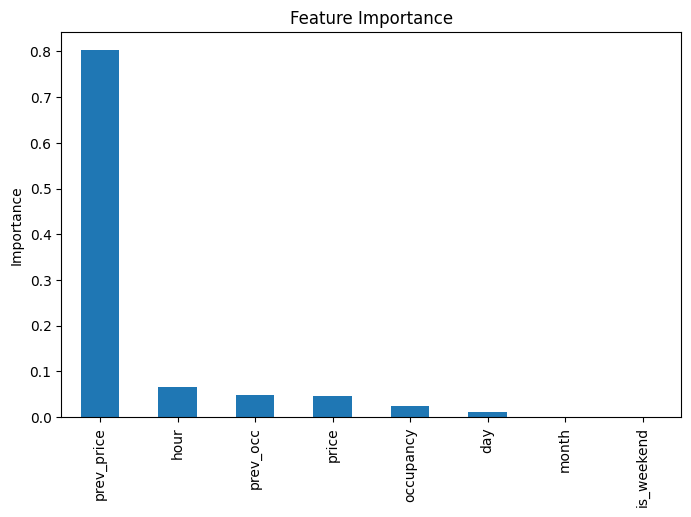

In [133]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

plt.figure(figsize=(8,5))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

### Key Findings

Feature importance analysis shows:

1. Previous Price is the most influential predictor.
2. Occupancy and Hour of Day are secondary drivers.
3. Day, Month, and Weekend indicators contribute relatively little information.

This suggests charging demand is strongly influenced by recent pricing behavior and station utilization patterns.

In [134]:
results = X_test.copy()

results["actual_demand"] = y_test.values
results["predicted_demand"] = y_pred

results.to_csv(
    "demand_predictions.csv",
    index=False
)

print("Saved demand_predictions.csv")

Saved demand_predictions.csv


## Experiment: Removing Previous Price

Since Previous Price dominates the model, a second experiment is conducted to evaluate model performance without this feature.

This helps determine whether demand can still be predicted accurately using operational and temporal variables alone.

In [135]:
X_no_prev = merged[
    [
        "occupancy",
        "price",
        "hour",
        "day",
        "month",
        "is_weekend"
    ]
]

split_idx = int(len(merged) * 0.8)

X_train = X_no_prev.iloc[:split_idx]
X_test = X_no_prev.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

rf2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf2.fit(X_train, y_train)

y_pred2 = rf2.predict(X_test)

mae2 = mean_absolute_error(y_test, y_pred2)
rmse2 = mean_squared_error(y_test, y_pred2) ** 0.5
r22 = r2_score(y_test, y_pred2)

print("MAE =", mae2)
print("RMSE =", rmse2)
print("R² =", r22)

MAE = 2.312269482303852
RMSE = 3.30071435295837
R² = 0.9233000882777034


### Comparison Results

Removing Previous Price causes a slight reduction in predictive performance.

However, the model still achieves strong accuracy, demonstrating that occupancy and temporal features contain significant predictive information.




# Demand Prediction Agent Findings

### Key Results

- Built a Random Forest demand forecasting model.
- Achieved an R² score of approximately 0.936.
- Previous Price was identified as the strongest predictor.
- Occupancy and Hour of Day also contributed significantly.
- Demand can still be predicted accurately without Previous Price.

### Conclusion

The Demand Prediction Agent successfully forecasts EV charging demand using historical operational data.

These demand forecasts will be used by the Tariff Pricing Agent to generate dynamic pricing recommendations and improve charging station efficiency.